# fine_tune_efd_find_cuts.ipynb

## Reference
See the [Cornell University Computational Optimization Open Textbook](https://optimization.cbe.cornell.edu/index.php?title=Differential_evolution#Software_Tools) for a good explanation of how the algorithm works.

In [1]:
from efd_find_cuts import efd_find_cuts
from sim_palm import generate_palm_with_cuts
# import pandas as pd
# from icecream import ic
# import random
from pympler import asizeof
import numpy as np
from scipy.optimize import differential_evolution
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
def create_trainset(num_cut_list=[0,1,2,3,4], nreps=100, random_seed=None):
    """ 
    Uses the generate_palm_wuth_cuts() function to create a training set.
    
    Result is a list of dicts. 
    Each dict contains numcuts (int), contour (polygon) and a binary mask (np array)
    
    For reproducing datasets, set a random seed before running this function. Example: random.seed(42)
    """
    trainset = []
    for num_cuts in num_cut_list:
        for rep in range(nreps):
            contour, mask = generate_palm_with_cuts(num_cuts)
            trainset.append({'num_cuts': num_cuts, 'contour': contour, 'mask': mask})
    print(f'Size of trainset is {asizeof.asizeof(trainset)/1000000} MB.')
    return trainset
    
# # Usage example:
# random.seed(42)
# training_data = create_trainset()

In [3]:
def estimate_defects(data, p1, p2):
    contour = data['contour']
    mask = data['mask']
    order = p1
    k = p2
    contours = efd_find_cuts(
        original_contour=contour,
        original_mask=mask,
        order=order,
        ksize=kernels[k])
    pred_ncuts = len(contours)
    return pred_ncuts


def objective_function(params, data):
    p1,p2 = [int(p) for p in params] 
    
    total_error = 0
    for d in data:
        prediction = estimate_defects(d, p1, p2)
        
        # We use Squared Error to penalize large outliers
        total_error += (prediction - d['num_cuts']) ** 2
    
    # Return Mean Squared Error
    return total_error / len(data)

# MAIN

## Find optimal parameters using Diferential Evolution

In [4]:
trainset = create_trainset(num_cut_list=[1, 2, 3], nreps=30, random_seed=42)

# Create a list odd rectangular kernels which may be used for morphological operations
kernels = [(3,3), (5,5), (7,7), (9,9)]

# Define the search space for p1 (EFD order) and p2 (k=index for kernels list)
# Format: (min, max) for each parameter
bounds = [(35,45), (0,3)]

print("Starting optimization...")

result = differential_evolution(
    func=objective_function, 
    bounds=bounds, 
    integrality=True,
    polish=False,
    args=(trainset,), # Passes training_data to the objective function
    workers=1,
    disp=True,
    updating="deferred" # prevents warning message
)

# --- 5. Results ---
if result.success:
    best_p1, best_p2 = np.round(result.x).astype(int)
    best_order = best_p1
    best_ksize = kernels[best_p2]
     
    print(f"Success! Optimized Parameters:")
    print(f"{best_order=}")
    print(f"{best_ksize=}")
    print(f"Mean squared error: {result.fun}")
else:
    print("Optimization failed:", result.message)

Size of trainset is 61.526536 MB.
Starting optimization...
differential_evolution step 1: f(x)= 0.6
differential_evolution step 2: f(x)= 0.6
differential_evolution step 3: f(x)= 0.6
differential_evolution step 4: f(x)= 0.6
differential_evolution step 5: f(x)= 0.6
differential_evolution step 6: f(x)= 0.6
differential_evolution step 7: f(x)= 0.6
differential_evolution step 8: f(x)= 0.6
differential_evolution step 9: f(x)= 0.6
differential_evolution step 10: f(x)= 0.6
differential_evolution step 11: f(x)= 0.6
Success! Optimized Parameters:
best_order=np.int64(43)
best_ksize=(7, 7)
Mean squared error: 0.6


## Plot confusion matrix

In [5]:
trainset = create_trainset(num_cut_list=[0, 1, 2, 3], nreps=30)

y_true = []
y_pred = []
label = []
for d in trainset:
    contours = efd_find_cuts(
        original_contour=d['contour'],
        original_mask=d['mask'],
        order=best_order,
        ksize=best_ksize
    )
    ncuts_detected = len(contours)
    y_true.append(d['num_cuts'])
    y_pred.append(ncuts_detected)
cm = confusion_matrix(y_true, y_pred)


Size of trainset is 82.024504 MB.


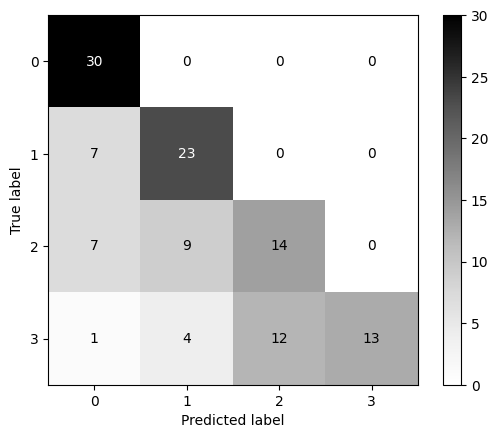

In [6]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Greys")
plt.show()

In [7]:
from sklearn.metrics import classification_report, accuracy_score

# Print all major metrics at once
print(classification_report(y_true, y_pred, zero_division=np.nan))

# Get a specific metric
# acc = accuracy_score(y_true, y_pred)


              precision    recall  f1-score   support

           0       0.67      1.00      0.80        30
           1       0.64      0.77      0.70        30
           2       0.54      0.47      0.50        30
           3       1.00      0.43      0.60        30

    accuracy                           0.67       120
   macro avg       0.71      0.67      0.65       120
weighted avg       0.71      0.67      0.65       120



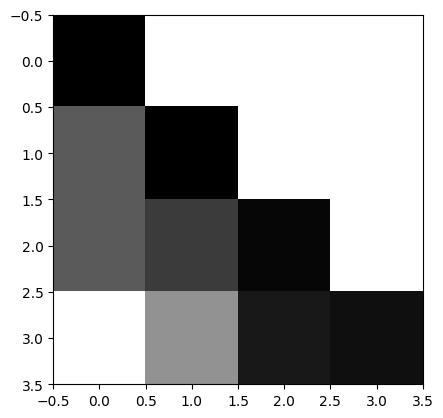

In [8]:
from matplotlib.colors import LogNorm
plt.imshow(cm, cmap='Greys', norm=LogNorm(vmin=1, vmax=cm.max()/2));